<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem002b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

════════════════════════════════════════════════════════════════════════════════
HES Bonding Simulation Results
════════════════════════════════════════════════════════════════════════════════
H-H        | covalent | Order: 0 | Shared: 1 e⁻ | Gain: 5
O-O        | covalent | Order: 1 | Shared: 2 e⁻ | Gain: 10
N-N        | covalent | Order: 1 | Shared: 3 e⁻ | Gain: 15
C-O        | covalent | Order: 1 | Shared: 2 e⁻ | Gain: 10
Na-Cl      | ionic    | Transferred: 1 e⁻ | ΔEN: 2.1 | Gain: 10
Mg-O       | ionic    | Transferred: 2 e⁻ | ΔEN: 2.3 | Gain: 20
H-O        | covalent | Order: 0 | Shared: 1 e⁻ | Gain: 5
C-C        | covalent | Order: 2 | Shared: 4 e⁻ | Gain: 20


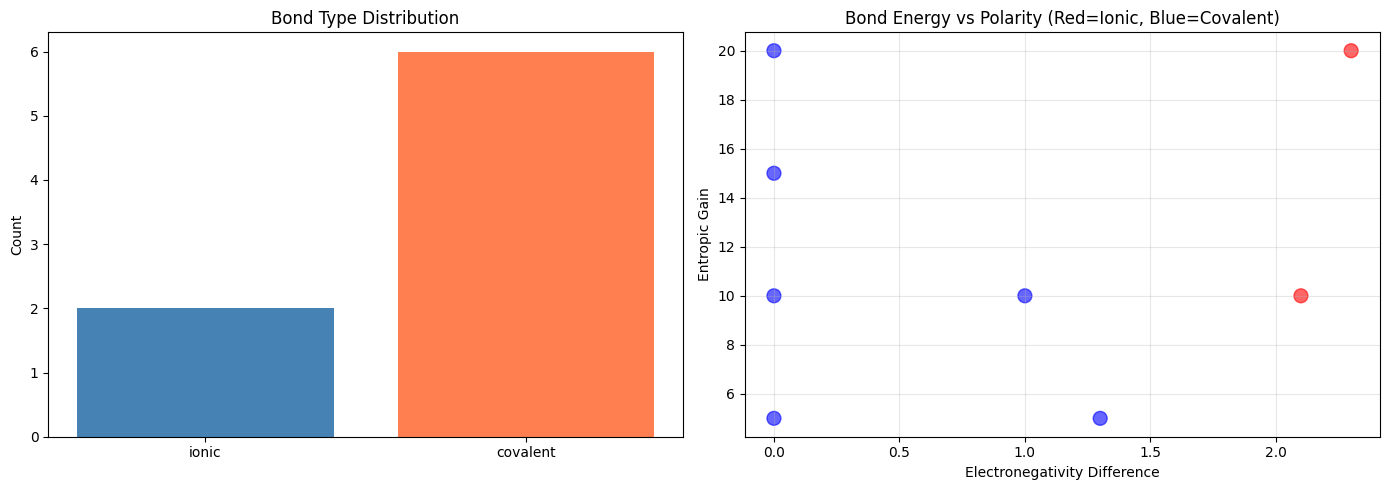


════════════════════════════════════════════════════════════════════════════════
Summary Statistics
════════════════════════════════════════════════════════════════════════════════
Average covalent bond gain: 10.8
Average ionic bond gain: 15.0
Covalent/Ionic ratio: 6/2


In [1]:
# Chem002_Fixed: HES Bonding with Octet Rule and Electronegativity Logic

import numpy as np
import matplotlib.pyplot as plt

# Define atoms with valence, target, and electronegativity
atoms = {
    "H":  {"Z": 1,  "valence": 1, "target": 2,  "electronegativity": 2.2},
    "C":  {"Z": 6,  "valence": 4, "target": 8,  "electronegativity": 2.5},
    "N":  {"Z": 7,  "valence": 5, "target": 8,  "electronegativity": 3.0},
    "O":  {"Z": 8,  "valence": 6, "target": 8,  "electronegativity": 3.5},
    "Na": {"Z": 11, "valence": 1, "target": 0,  "electronegativity": 0.9},
    "Mg": {"Z": 12, "valence": 2, "target": 0,  "electronegativity": 1.2},
    "Cl": {"Z": 17, "valence": 7, "target": 8,  "electronegativity": 3.0},
}

# Calculate bonding need
for atom in atoms.values():
    atom["need"] = atom["target"] - atom["valence"]

# HES bonding model
def simulate_bond(atom1_name, atom2_name):
    a1 = atoms[atom1_name]
    a2 = atoms[atom2_name]
    en_diff = abs(a1["electronegativity"] - a2["electronegativity"])

    # Ionic bond logic
    if en_diff > 1.7 and (a1["need"] < 0 or a2["need"] < 0):
        donor = atom1_name if a1["need"] < 0 else atom2_name
        transferred = abs(atoms[donor]["need"])
        return {
            "pair": f"{atom1_name}-{atom2_name}",
            "bond_type": "ionic",
            "bond_order": 0,
            "shared_electrons": 0,
            "transferred_electrons": transferred,
            "entropic_gain": transferred * 10,
            "EN_diff": en_diff
        }
    else:
        shared = min(abs(a1["need"]), abs(a2["need"]))
        return {
            "pair": f"{atom1_name}-{atom2_name}",
            "bond_type": "covalent",
            "bond_order": shared // 2,
            "shared_electrons": shared,
            "transferred_electrons": 0,
            "entropic_gain": shared * 5,
            "EN_diff": en_diff
        }

# Test molecular pairs
pairs = [
    ("H", "H"), ("O", "O"), ("N", "N"), ("C", "O"),
    ("Na", "Cl"), ("Mg", "O"), ("H", "O"), ("C", "C")
]

results = [simulate_bond(a1, a2) for a1, a2 in pairs]

# Display results
print("═" * 80)
print("HES Bonding Simulation Results")
print("═" * 80)
for r in results:
    if r["bond_type"] == "ionic":
        print(f"{r['pair']:10} | {r['bond_type']:8} | Transferred: {r['transferred_electrons']} e⁻ | "
              f"ΔEN: {r['EN_diff']:.1f} | Gain: {r['entropic_gain']}")
    else:
        print(f"{r['pair']:10} | {r['bond_type']:8} | Order: {r['bond_order']} | "
              f"Shared: {r['shared_electrons']} e⁻ | Gain: {r['entropic_gain']}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bond Type Distribution
bond_types = [r["bond_type"] for r in results]
type_counts = {bt: bond_types.count(bt) for bt in set(bond_types)}
ax1.bar(type_counts.keys(), type_counts.values(), color=['steelblue', 'coral'])
ax1.set_title("Bond Type Distribution")
ax1.set_ylabel("Count")

# Plot 2: Entropic Gain vs EN Difference
en_diffs = [r["EN_diff"] for r in results]
gains = [r["entropic_gain"] for r in results]
colors = ['red' if r["bond_type"]=="ionic" else 'blue' for r in results]
ax2.scatter(en_diffs, gains, c=colors, s=100, alpha=0.6)
ax2.set_xlabel("Electronegativity Difference")
ax2.set_ylabel("Entropic Gain")
ax2.set_title("Bond Energy vs Polarity (Red=Ionic, Blue=Covalent)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "═" * 80)
print("Summary Statistics")
print("═" * 80)
covalent_gains = [r["entropic_gain"] for r in results if r["bond_type"] == "covalent"]
ionic_gains = [r["entropic_gain"] for r in results if r["bond_type"] == "ionic"]
print(f"Average covalent bond gain: {np.mean(covalent_gains):.1f}")
print(f"Average ionic bond gain: {np.mean(ionic_gains):.1f}")
print(f"Covalent/Ionic ratio: {len(covalent_gains)}/{len(ionic_gains)}")
